In [1]:
import logging
import os
import sys
import traceback
from tqdm import tqdm 

from hydra import initialize, compose
import numpy as np
import pandas as pd
from omegaconf import DictConfig
import scanpy as sc
import torch

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import sys 
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import get_forward_model

from torch.utils.data import TensorDataset, DataLoader

In [2]:
with initialize(config_path="../../../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus"
                    ])

In [3]:
config["paths"]["ct_classifier_path"] = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/easy-monkey-341_TargetPredictionModel.pkl" 

In [4]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Classify both training and validation anndata 

In [5]:
train_data = target_prediction_model.train_data.state_data
valid_data = target_prediction_model.validation_data.state_data

In [6]:
label_train = target_prediction_model.train_data.adata.obs.cell_type.to_numpy()
label_valid = target_prediction_model.validation_data.adata.obs.cell_type.to_numpy()

In [7]:
X_concat = torch.from_numpy(np.concatenate([train_data, valid_data], axis=0))
label_concat = np.concatenate([label_train, label_valid])

## Tensor dataset for data 

In [8]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(X_concat), 
    batch_size=4026,
    shuffle=False
)

In [9]:
ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())

100%|██████████| 118/118 [00:23<00:00,  5.11it/s]


In [10]:
ct_predictions = np.concatenate(ct_predictions)

In [11]:
from sklearn.preprocessing import LabelEncoder

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [12]:
ct_predictions_str = classes[ct_predictions]

In [13]:
pd.DataFrame(ct_predictions_str).value_counts()

0          
MPP            82945
GMP-Neutro     74833
MgKEryPro1     62308
LMPP-CLP       39495
Early_GMP      36880
EosBasMast2    31427
GMP_cycling    28517
MPP_MgkEry     24622
EosBasMast1    22713
MgKEryPro2     20797
EryPro         16768
CyclingPro1    10079
late_MgkPro     4462
HSCs            2622
earlyMPP        2329
pre_cDC2        2222
EosBasMast3     1914
MLP             1615
preProB         1591
CD16Mono        1221
CyclingPro2      941
pre_cDC1         705
CD14Mono         665
ProB             165
Name: count, dtype: int64

In [14]:
ct_predictions_str

array(['Early_GMP', 'MPP', 'CD14Mono', ..., 'GMP-Neutro', 'LMPP-CLP',
       'MPP'], shape=(471836,), dtype='<U11')

In [15]:
label_concat

array(['Early_GMP', 'MPP', 'CD14Mono', ..., 'GMP-Neutro', 'Early_GMP',
       'MPP'], shape=(471836,), dtype=object)

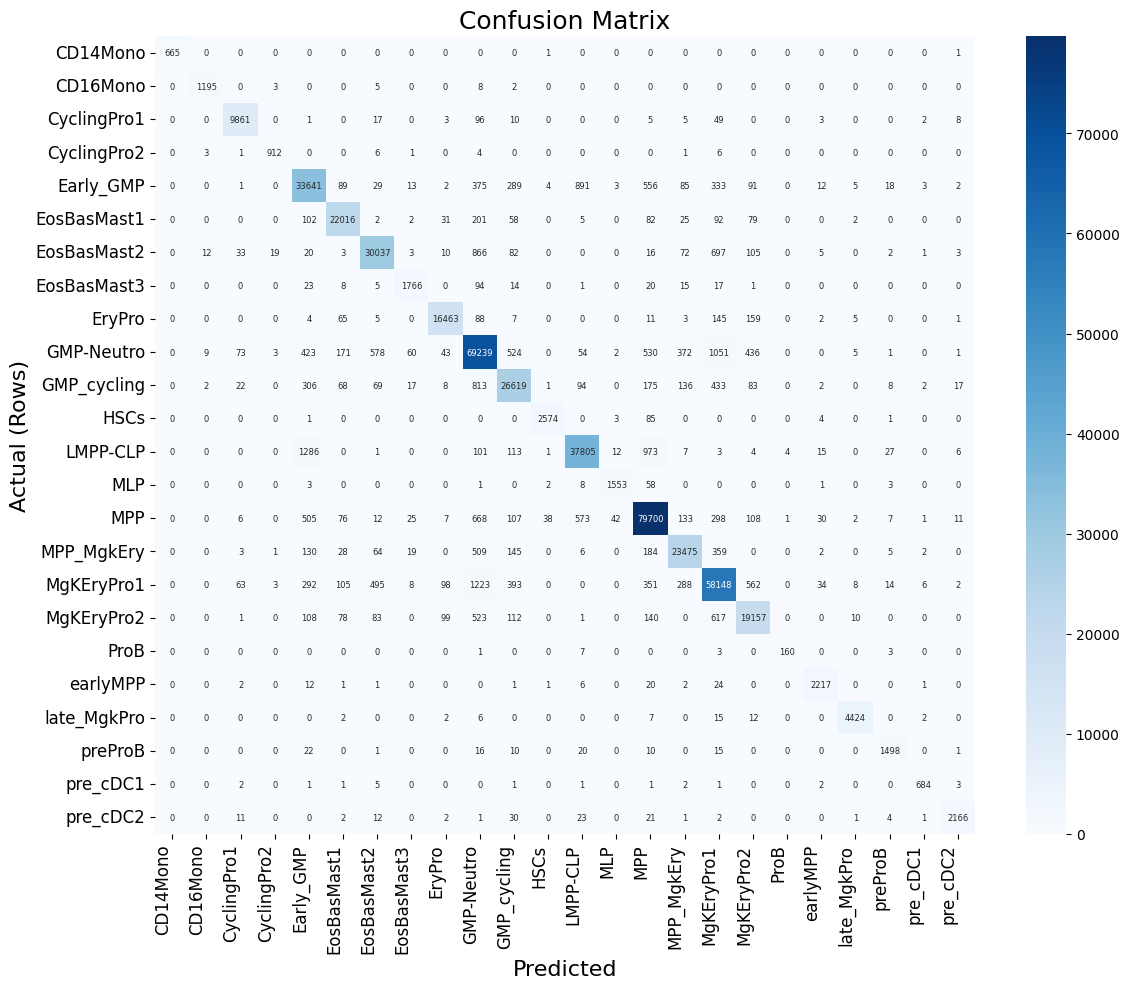

In [16]:
cm = confusion_matrix(label_concat, ct_predictions_str)

# Get labels (adjust if you have a predefined order)
labels = sorted(set(label_concat))

plt.figure(figsize=(12, 10))  # bigger figure

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 6}  # bigger numbers
)

plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual (Rows)", fontsize=16)
plt.title("Confusion Matrix", fontsize=18)

plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import classification_report

In [18]:
pd.DataFrame(classification_report(label_concat, ct_predictions_str, output_dict=True)).T

,precision,recall,f1-score,support
CD14Mono,1.000000,0.997001,0.998498,667.000000
CD16Mono,0.978706,0.985161,0.981923,1213.000000
CyclingPro1,0.978371,0.980219,0.979294,10060.000000
CyclingPro2,0.969182,0.976445,0.972800,934.000000
Early_GMP,0.912175,0.923138,0.917624,36442.000000
EosBasMast1,0.969313,0.969996,0.969654,22697.000000
EosBasMast2,0.955771,0.939067,0.947345,31986.000000
EosBasMast3,0.922675,0.899185,0.910779,1964.000000
EryPro,0.981811,0.970810,0.976279,16958.000000
GMP-Neutro,0.925247,0.941067,0.933090,73575.000000


In [19]:
adata_concat = sc.AnnData(X=X_concat.cpu().numpy(),
                          obs=pd.DataFrame({"cell_type": ct_predictions_str}))

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [20]:
sc.pp.subsample(adata_concat, n_obs=100_000,  random_state=42)

In [21]:
sc.tl.pca(adata_concat)
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)

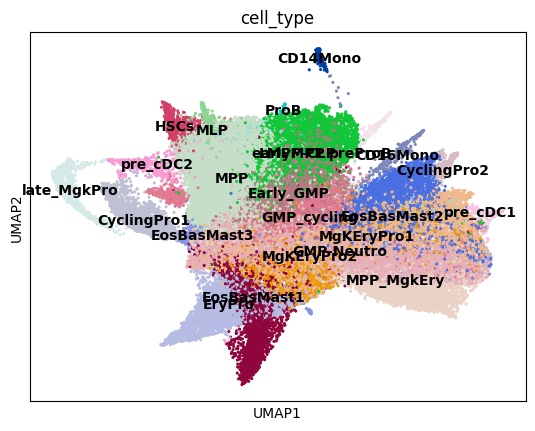

In [22]:
sc.pl.umap(adata_concat, color="cell_type", legend_loc="on data", s=20)

In [23]:
adata_concat = adata_concat[:, :20]

In [24]:
sc.tl.pca(adata_concat)
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


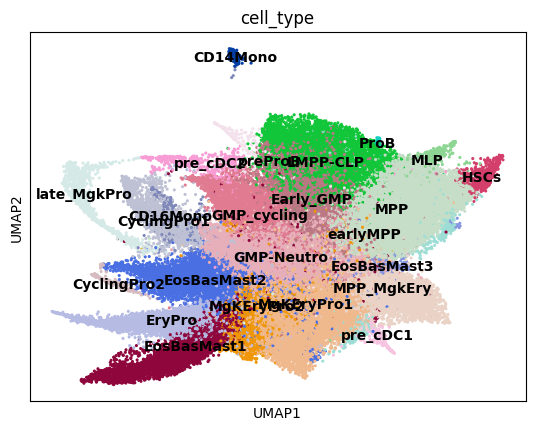

In [25]:
sc.pl.umap(adata_concat, color="cell_type", legend_loc="on data", s=20)